In [ ]:
from google.colab import drive
import pandas as pd

drive.mount('/content/drive')


df = pd.read_csv('/content/drive/MyDrive/Sample - Superstore.csv', encoding='cp1252')

df.head()


Mounted at /content/drive


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


# Task 1

Sales Skewness: 12.97275234181623
Sales Mean: 229.85800083049833
Sales Skewness: 54.489999999999995


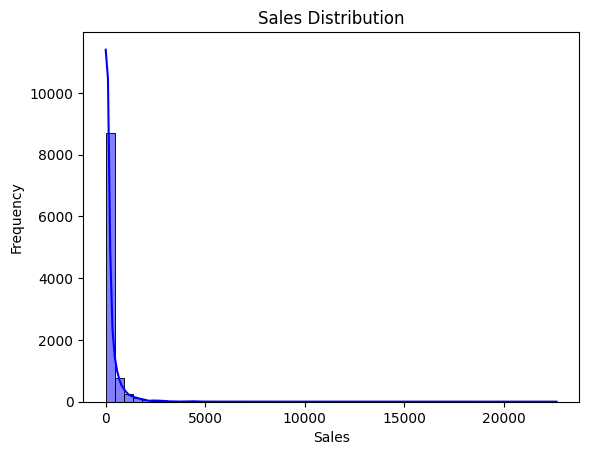

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(df['Sales'], kde=True, color='blue', bins=50)
plt.title('Sales Distribution')
plt.xlabel('Sales')
plt.ylabel('Frequency')
sales_skew = df['Sales'].skew()
sales_mean = df['Sales'].mean()
sales_median = df['Sales'].median()
print(f'Sales Skewness: {sales_skew}')
print(f'Sales Mean: {sales_mean}')
print(f'Sales Skewness: {sales_median}')

plt.show()

#the great difference between the mean and median show that the distribution is extremely right-skewed. The high skewness value shows how misleading using mean to summarize the data is.

# Task 2

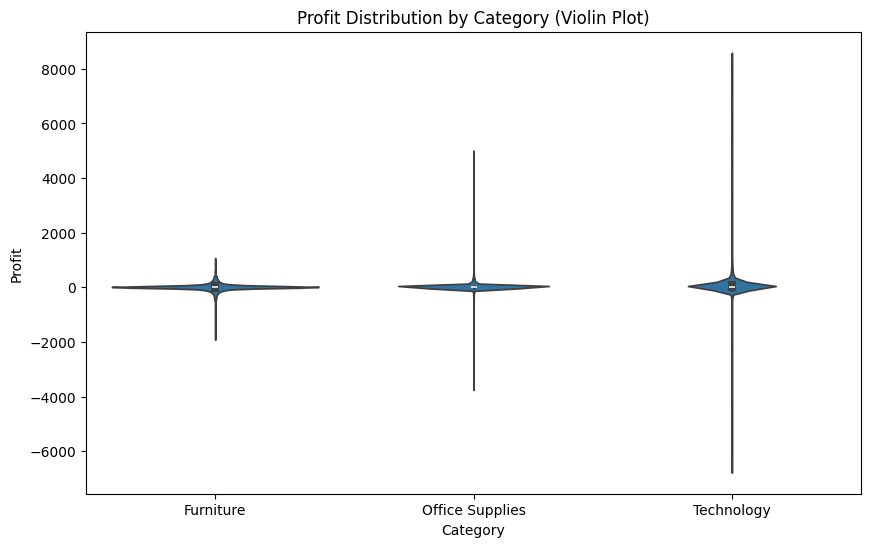

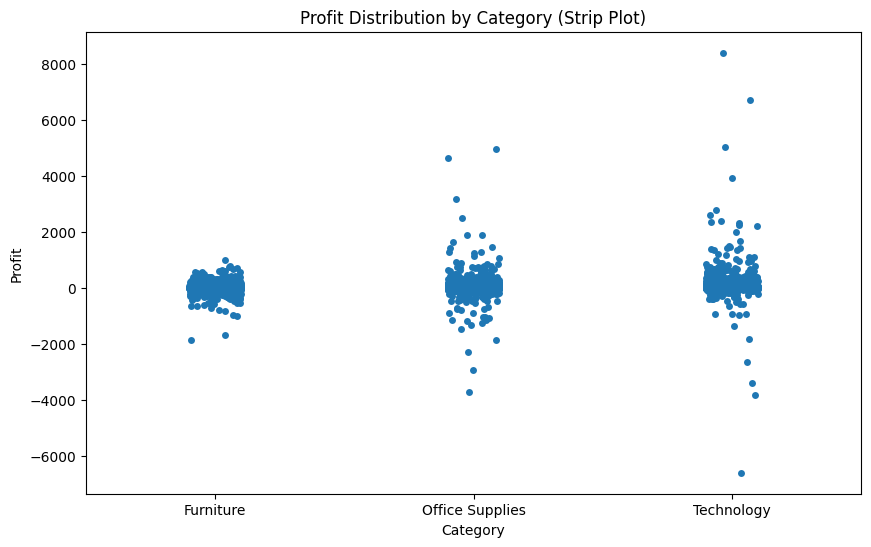

In [ ]:
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x='Category', y='Profit')
plt.title('Profit Distribution by Category (Violin Plot)')
plt.xlabel('Category')
plt.ylabel('Profit')
plt.show()

plt.figure(figsize=(10, 6))
sns.stripplot(data=df, x='Category', y='Profit')
plt.title('Profit Distribution by Category (Strip Plot)')
plt.xlabel('Category')
plt.ylabel('Profit')
plt.show()


#a violin plot is better at revealing a category with a bimodal as it shows two peaks where data clusters. For unusually spread-out profit distribution, violin plots show how far the data stretches through its tails

# Task 3

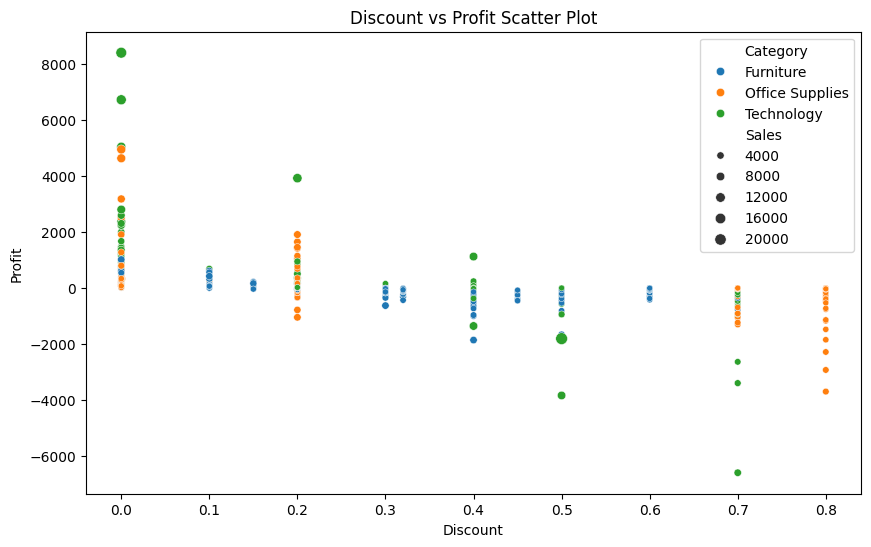

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Discount', y='Profit', hue='Category', size='Sales')
plt.title('Discount vs Profit Scatter Plot')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.show()

#At high discounts technology products tend to have large losses, while Office Supplies also show losses but less

# Task 4

               Row ID  Postal Code     Sales  Quantity  Discount    Profit
Row ID       1.000000     0.009671 -0.001359 -0.004016  0.013480  0.012497
Postal Code  0.009671     1.000000 -0.023854  0.012761  0.058443 -0.029961
Sales       -0.001359    -0.023854  1.000000  0.200795 -0.028190  0.479064
Quantity    -0.004016     0.012761  0.200795  1.000000  0.008623  0.066253
Discount     0.013480     0.058443 -0.028190  0.008623  1.000000 -0.219487
Profit       0.012497    -0.029961  0.479064  0.066253 -0.219487  1.000000
               Row ID  Postal Code     Sales  Quantity  Discount    Profit
Row ID       1.000000     0.011466 -0.001310 -0.002416  0.012655 -0.010545
Postal Code  0.011466     1.000000 -0.002059  0.013952  0.052793 -0.005451
Sales       -0.001310    -0.002059  1.000000  0.327426 -0.056969  0.518407
Quantity    -0.002416     0.013952  0.327426  1.000000 -0.000878  0.234491
Discount     0.012655     0.052793 -0.056969 -0.000878  1.000000 -0.543350
Profit      -0.010545    

Text(0, 0.5, 'Profit')

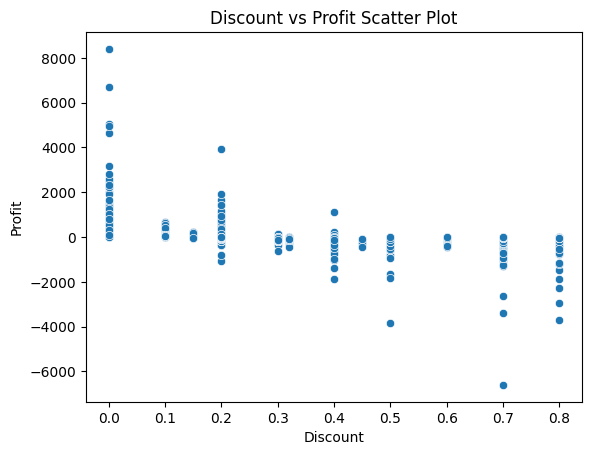

In [ ]:
corr_matrix_pearson = df.select_dtypes(include='number').corr(method='pearson')
print(corr_matrix_pearson)

corr_matrix_spearman = df.select_dtypes(include='number').corr(method='spearman')
print(corr_matrix_spearman)

sns.scatterplot(data=df, x='Discount', y='Profit')
plt.title('Discount vs Profit Scatter Plot')
plt.xlabel('Discount')
plt.ylabel('Profit')

#s the relationship is more strongly negative in terms of rank/order than as a straight-line relationship, likely because of outliers or a non-linear pattern in the scatter plot.

# Task 5

Category    Furniture  Office Supplies  Technology           All
Region                                                          
Central   163797.1638       167026.415  170416.312  5.012399e+05
East      208291.2040       205516.055  264973.981  6.787812e+05
South     117298.6840       125651.313  148771.908  3.917219e+05
West      252612.7435       220853.249  251991.832  7.254578e+05
All       741999.7953       719047.032  836154.033  2.297201e+06


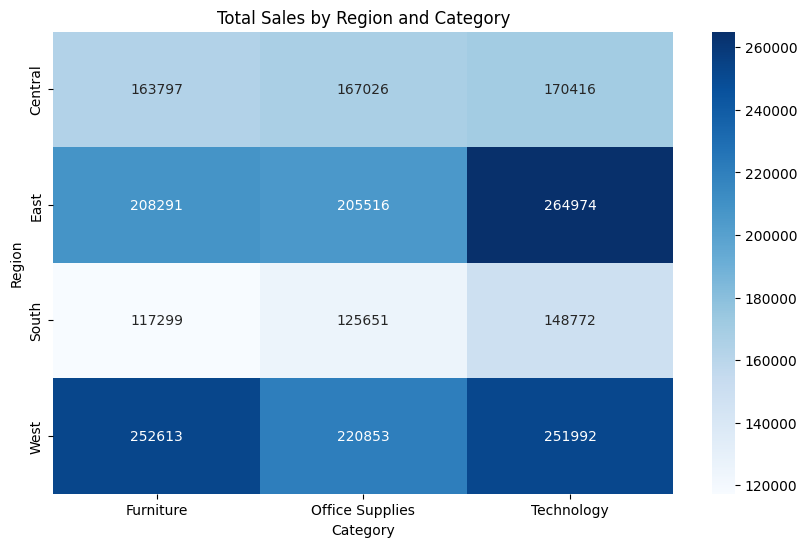

In [ ]:

pivot = pd.pivot_table(df, values='Sales', index='Region', columns='Category', aggfunc='sum', margins=True)

print(pivot)
heatmap_data = pivot.drop(index='All').drop(columns='All')

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data,annot=True,fmt=".0f",cmap="Blues")

plt.title("Total Sales by Region and Category")
plt.xlabel("Category")
plt.ylabel("Region")
plt.show()

#Technology and East contributes most to overall revenue.

# Task 6

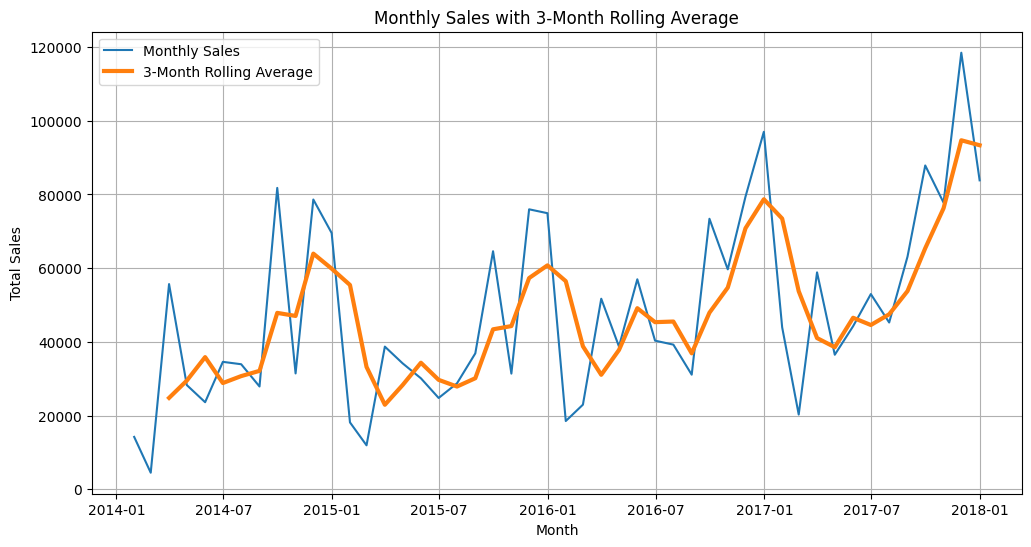

In [ ]:
monthly_sales = df['Sales'].resample('ME').sum()

rolling_avg = monthly_sales.rolling(window=3).mean()

plt.figure(figsize=(12, 6))

plt.plot(monthly_sales, label='Monthly Sales')
plt.plot(rolling_avg, label='3-Month Rolling Average', linewidth=3)

plt.title('Monthly Sales with 3-Month Rolling Average')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.legend()
plt.grid(True)

plt.show()


#The 3-month rolling average smooths out short-term fluctuations and noise, making the overall sales trend easier to see. It reveals whether sales are generally increasing or decreasing over time


# Task 7

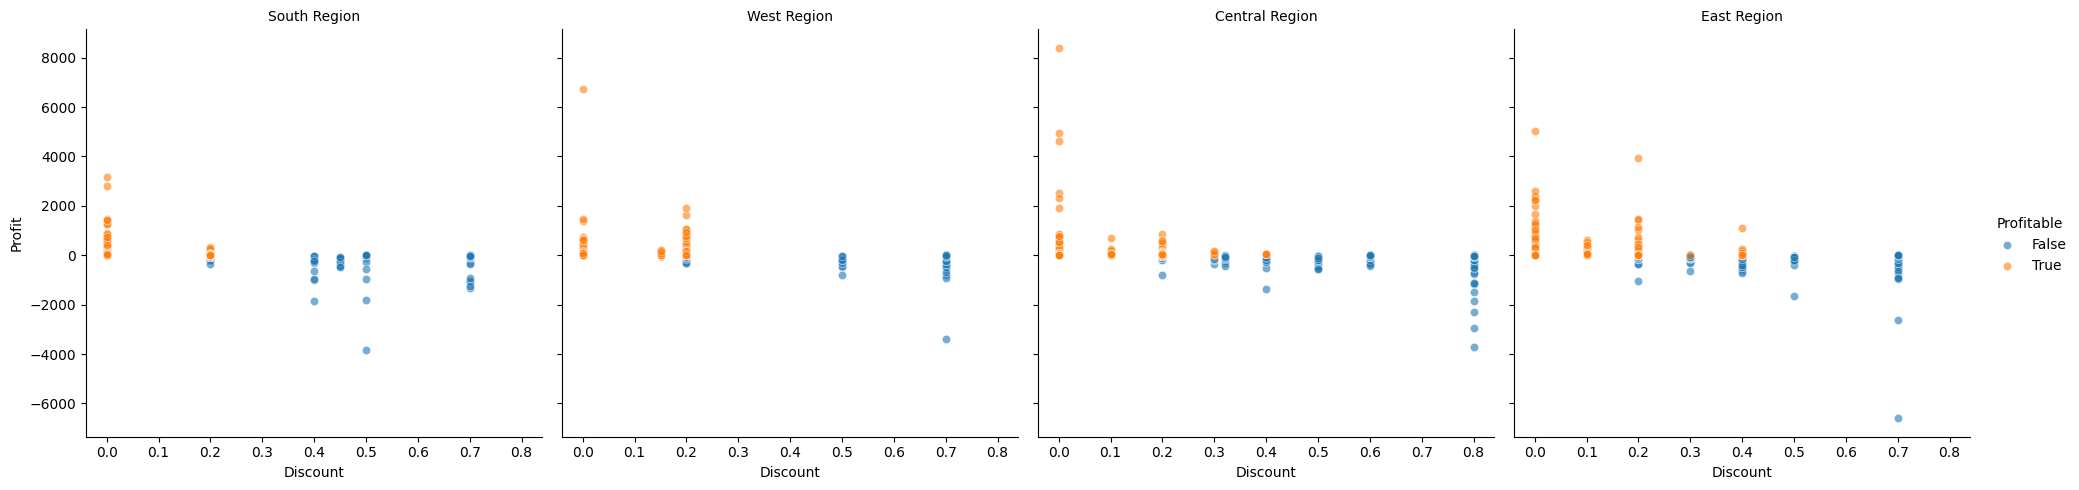

In [ ]:
df['Profitable'] = df['Profit'] > 0

g = sns.FacetGrid(df, col='Region', hue='Profitable', height=5, aspect=1)

g.map_dataframe(sns.scatterplot, x='Discount', y='Profit',alpha=0.6)

g.add_legend()

g.set_axis_labels('Discount', 'Profit')
g.set_titles('{col_name} Region')

plt.show()

# the central region shows a visibly different discount–profit relationship,with higher discounts being more strongly associated with negative profit.



# Task 8

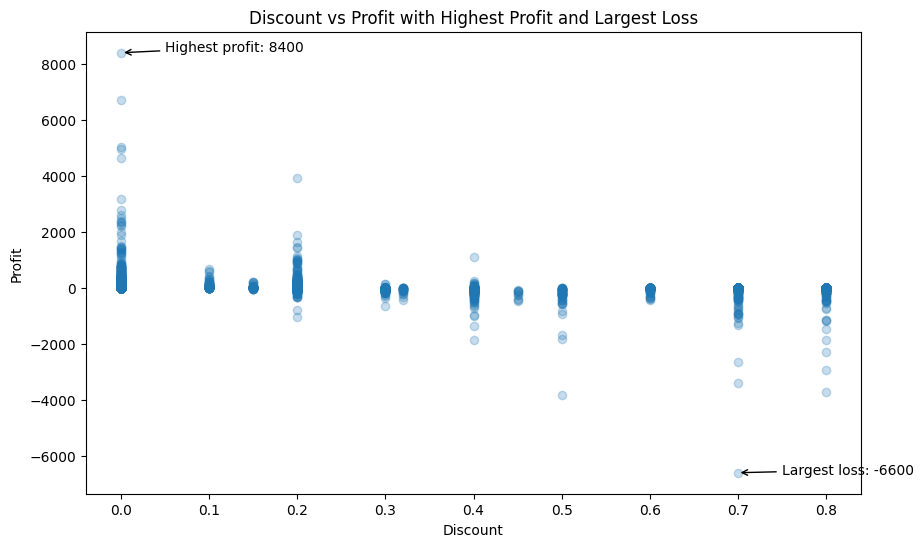

In [ ]:
df = df.loc[:, ~df.columns.duplicated()].copy()

df['Profit'] = pd.to_numeric(df['Profit'], errors='coerce')
df['Discount'] = pd.to_numeric(df['Discount'], errors='coerce')
plot_df = df[['Discount', 'Profit']].dropna().reset_index(drop=True)

bestidx = plot_df['Profit'].argmax()
worstidx = plot_df['Profit'].argmin()

best_discount = plot_df.loc[bestidx, 'Discount']
best_profit = plot_df.loc[bestidx, 'Profit']

worst_discount = plot_df.loc[worstidx, 'Discount']
worst_profit = plot_df.loc[worstidx, 'Profit']

plt.figure(figsize=(10, 6))

plt.scatter(plot_df['Discount'],plot_df['Profit'],alpha=0.25)

plt.annotate(f'Highest profit: {best_profit:.0f}',xy=(best_discount, best_profit),xytext=(best_discount + 0.05, best_profit + 50),arrowprops=dict(arrowstyle='->'))

plt.annotate(f'Largest loss: {worst_profit:.0f}',xy=(worst_discount, worst_profit),xytext=(worst_discount + 0.05, worst_profit - 50),arrowprops=dict(arrowstyle='->'))

plt.xlabel('Discount')
plt.ylabel('Profit')
plt.title('Discount vs Profit with Highest Profit and Largest Loss')
plt.show()
